UCI Nursery Data Set: https://www.kaggle.com/datasets/heitornunes/nursery/data/code


In [ ]:
# Import tools
import pandas as pd
from sklearn.naive_bayes import CategoricalNB   # Naive Bayes for category data
from sklearn.preprocessing import LabelEncoder  # Converts words to numbers
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Check how well the model did
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load dataset
df = pd.read_csv("nursery.csv")
df.head()

In [ ]:
# dataset overview
df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   parents           12960 non-null  object
 1   has_nurs          12960 non-null  object
 2   form              12960 non-null  object
 3   children          12960 non-null  object
 4   housing           12960 non-null  object
 5   finance           12960 non-null  object
 6   social            12960 non-null  object
 7   health            12960 non-null  object
 8   final evaluation  12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB
(12960, 9)


In [ ]:
# rename columns
df = df.rename(columns={
    "parents": "parents_occupation",
    "has_nurs": "nursery_condition",
    "form": "family_structure",
    "housing": "housing_condition",
    "finance": "financial_status",
    "social": "social_condition",
    "health": "health_priority"
})

In [ ]:
# view output label distribution
print(df['final evaluation'].value_counts())

final evaluation
not_recom     4320
priority      4266
spec_prior    4044
very_recom     328
recommend        2
Name: count, dtype: int64


In [ ]:
# drop the recommend class due to too few samples (2 rows)
df = df[df["final evaluation"] != "recommend"]  # model cannot learn meaningful patterns from such small sample

In [ ]:
# Create a separate encoder for each column
encoder_parents  = LabelEncoder()
encoder_has_nurs = LabelEncoder()
encoder_children = LabelEncoder()
encoder_form   = LabelEncoder()
encoder_housing   = LabelEncoder()
encoder_finance = LabelEncoder()
encoder_social = LabelEncoder()
encoder_health = LabelEncoder()
encoder_label = LabelEncoder()

# fit_transform the categories and convert to numbers
df["parents_occupation"] = encoder_parents.fit_transform(df["parents_occupation"])
df["nursery_condition"] = encoder_has_nurs.fit_transform(df["nursery_condition"])
df["children"] = encoder_children.fit_transform(df["children"])
df["family_structure"] = encoder_form.fit_transform(df["family_structure"])
df["housing_condition"] = encoder_housing .fit_transform(df["housing_condition"])
df["financial_status"] = encoder_finance.fit_transform(df["financial_status"])
df["social_condition"] = encoder_social.fit_transform(df["social_condition"])
df["health_priority"] = encoder_health.fit_transform(df["health_priority"])
df["final evaluation"] = encoder_label.fit_transform(df["final evaluation"])


print('\n After converting words to numbers:','\n',df)
print()


 After converting words to numbers: 
        parents_occupation  nursery_condition  family_structure  children  \
1                       2                  3                 0         0   
2                       2                  3                 0         0   
4                       2                  3                 0         0   
5                       2                  3                 0         0   
6                       2                  3                 0         0   
...                   ...                ...               ...       ...   
12955                   0                  4                 2         3   
12956                   0                  4                 2         3   
12957                   0                  4                 2         3   
12958                   0                  4                 2         3   
12959                   0                  4                 2         3   

       housing_condition  financial_status  soci

In [ ]:
# define the X features and y (output label)
X = df.drop(["final evaluation"], axis=1)  # Input features
y = df["final evaluation"]                 # Output label

In [ ]:
# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,      # Same split every run (reproducible)
    stratify=y           # Keeps class distribution the same in train and test sets
)

In [ ]:
# Train dataset with CategoricalNB Naive Bayes model
model = CategoricalNB()   # Create an empty model
model.fit(X_train, y_train)        # Train model on training set

# predict on the model with text set
y_predicted = model.predict(X_test)   # Model predicts each final evaluation

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_predicted)   # % of correct guesses
print(f"Accuracy: {accuracy * 100:.2f}%")

# Classification Report for model
print("\nClassification Report:\n", classification_report(y_test, y_predicted))   # display metrics to evaluate model

Accuracy: 90.47%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       864
           1       0.83      0.90      0.86       853
           2       0.89      0.88      0.89       809
           3       0.75      0.05      0.09        66

    accuracy                           0.90      2592
   macro avg       0.87      0.71      0.71      2592
weighted avg       0.90      0.90      0.90      2592



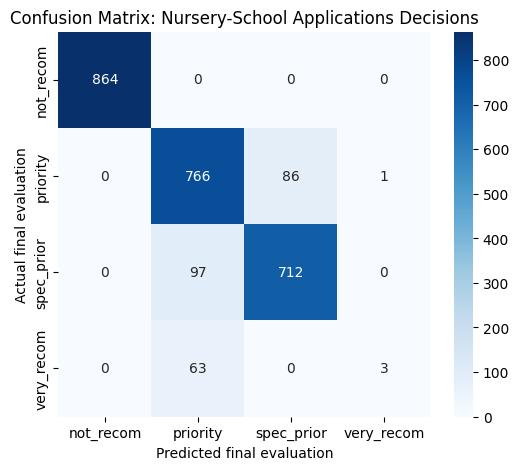

In [ ]:
# Confusion matrix  -- see how nursery-school applications are being predicted vs actual
cm = confusion_matrix(y_test, y_predicted)

# define class labels for plot
labels = encoder_label.classes_

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels= labels, yticklabels=labels)
plt.xlabel('Predicted final evaluation')
plt.ylabel('Actual final evaluation')
plt.title('Confusion Matrix: Nursery-School Applications Decisions')
plt.show()

In [ ]:
# Prepare a provision for a new data entry and its prediction of an outcome.

def predict_application_decision():
    while True:
        try:
            occupation_of_parents = input("Enter type of parents' occupation (great_pret (great pretension), pretentious, usual): ")
            nursery_condition = input("Enter condition of nursery: (proper, less proper, improper, critical, very_crit (very critical)): ")
            family_structure = input("Enter structure of family (complete, completed, incomplete, foster): ")
            num_children = input("Enter number of children in family (1, 2, 3, more): ")
            housing_condition = input("Enter housing condition (convenient, less_conv (less convenient), critical): ")
            financial_status = input("Enter financial standing of family (convenient, inconv (inconvenient)): ")
            social_condition = input("Enter social condition of family (nonprob (non-problematic), slightly_prob (slightly problematic), problematic): ")
            health_status_priority = input("Enter the health-based priority for this application (not_recom (acceptance is not recommended), recommended (acceptance is recommended), priority (priority acceptance is recommended): ")


            # input validation for type of parents' occupation
            if occupation_of_parents not in encoder_parents.classes_:
              print("Error: Please enter exact wording for type of parents' occupation.")
              continue  #restart the loop

            # input validation for nursery condition
            if nursery_condition not in encoder_has_nurs.classes_:
              print("Error: Please enter exact wording for condition of nursery.")
              continue  #restart the loop

            # input validation for family structure
            if family_structure not in encoder_form.classes_:
              print("Error: Please enter accepted values.")
              continue  #restart the loop

            # input validation for number of children in family
            if num_children not in encoder_children.classes_:
              print("Error: Please enter accepted values.")
              continue  #restart the loop

            # input validation for housing condition
            if housing_condition not in encoder_housing.classes_:
              print("Error: Please enter accepted values.")
              continue  #restart the loop

            # input validation for financial status
            if financial_status not in encoder_finance.classes_:
              print("Error: Please enter accepted values.")
              continue  #restart the loop

            # input validation for social condition of family
            if social_condition not in encoder_social.classes_:
              print("Error: Please enter accepted values.")
              continue  #restart the loop

            # input validation for health priority
            if health_status_priority not in encoder_health.classes_:
              print("Error: Please enter accepted values.")
              continue  #restart the loop


            # use same label encoder to encode inputs
            occupation_of_parents = encoder_parents.transform([occupation_of_parents])[0]
            nursery_condition = encoder_has_nurs.transform([nursery_condition])[0]
            family_structure = encoder_form.transform([family_structure])[0]
            num_children = encoder_children.transform([num_children])[0]
            housing_condition = encoder_housing.transform([housing_condition])[0]
            financial_status = encoder_finance.transform([financial_status])[0]
            social_condition = encoder_social.transform([social_condition])[0]
            health_status_priority = encoder_health.transform([health_status_priority])[0]


            # create new customer dataframe from user input
            new_applicant = pd.DataFrame([[occupation_of_parents, nursery_condition, family_structure, num_children, housing_condition, financial_status, social_condition, health_status_priority]],
                                           columns=['parents_occupation', 'nursery_condition', 'family_structure', 'children', 'housing_condition', 'financial_status', 'social_condition', 'health_priority'])

            # Make prediction
            prediction = model.predict(new_applicant)[0]
            # Make probabilities
            probability = model.predict_proba(new_applicant)[0]

            # Convert number back to final decision values
            result = encoder_label.inverse_transform([prediction])[0]


            # print result
            print(f"Prediction: The application is likely to be {result}.")

            # print proabablity of each outcome
            print(f"  --> Probability {encoder_label.classes_[0]}: {probability[0]*100:.1f}%")
            print(f"  --> Probability {encoder_label.classes_[1]}: {probability[1]*100:.1f}%")
            print(f"  --> Probability {encoder_label.classes_[2]}: {probability[2]*100:.1f}%")
            print(f"  --> Probability {encoder_label.classes_[3]}: {probability[3]*100:.1f}%")


            # ask user for another input
            another_applicant = input("Enter data for another applicant? (yes/no): ")
            if another_applicant.lower() != 'yes':
                break #exit loop
        except ValueError:
            print("Invalid input. Please enter valid values.")

predict_application_decision()

Enter type of parents' occupation (great_pret (great pretension), pretentious, usual): great_pret
Enter condition of nursery: (proper, less proper, improper, critical, very_crit (very critical)): very_crit
Enter structure of family (complete, completed, incomplete, foster): incomplete
Enter number of children in family (1, 2, 3, more): more
Enter housing condition (convenient, less_conv (less convenient), critical): critical
Enter financial standing of family (convenient, inconv (inconvenient)): inconv
Enter social condition of family (nonprob (non-problematic), slightly_prob (slightly problematic), problematic): problematic
Enter the health-based priority for this application (not_recom (acceptance is not recommended), recommended (acceptance is recommended), priority (priority acceptance is recommended): priority
Prediction: The application is likely to be spec_prior.
  --> Probability not_recom: 0.0%
  --> Probability priority: 1.4%
  --> Probability spec_prior: 98.6%
  --> Probabil

The Nursery dataset was used to build a model to categorize the applications for nursery school ranking the applications according to the level of urgency or recommendations it should be evaluated as. The dataset contains 8 distinct categories that relate to the living standards, financial standing, family structure, and health factors. The original evaluation of application had 5 possible outcomes: not recommended, recommend, very recommend, priority acceptance, and special priority. Since all the features were categorical, the Naive Bayes model CategoricalNB, was a good fit for the dataset. CategoricalNB handles the multi-category features. To build the model, all categorical variables were encoded to integer and then the data was split into a testing and training set. During model evaluation, it was found there were only 2 cases of the “recommend” class. This was insufficient for effective training, so the class was dropped. The model overall had a high accuracy of 90.47%. Looking closer at the class performances in the target feature, 3 out of the 4 had good balanced metrics, with “not recommended" being perfect across the board. The “very recommended” class struggled, while it was decently accurate when the model did predict the class, it failed to identify more than 90% of the cases as whole. In fact, it was more likely to falsely be predicted as “priority” instead of its actual case. This trade off might not be too drastic, as at least it is not being predicted the opposite ranking of “not recommended." Aside from the poor performance of the “very recommended” class, the other classes performed well and the model on the whole has a strong overall measure.
